# Import necessary depencencies

In [1]:
import pandas as pd
import numpy as np
import text_normalizer as tn
import model_evaluation_utils as meu

np.set_printoptions(precision=2, linewidth=80)

# Load and normalize data

In [ ]:
%%time
dataset = pd.read_csv('movie_reviews.csv.bz2', compression='bz2')

# take a peek at the data
print(dataset.head())
reviews = np.array(dataset['review'])
sentiments = np.array(dataset['sentiment'])

# build train and test datasets
train_reviews = reviews[:35000]
train_sentiments = sentiments[:35000]
test_reviews = reviews[35000:]
test_sentiments = sentiments[35000:]

# Traditional Supervised Machine Learning Models

## Feature Engineering

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from pickle import Unpickler
with open('norm_train_reviews.p', 'rb') as train_file:
    norm_train_reviews = Unpickler(train_file).load()

with open('norm_test_reviews.p', 'rb') as test_file:
    norm_test_reviews = Unpickler(test_file).load()

# build BOW features on train reviews
cv = CountVectorizer(binary=False, min_df=0.0, max_df=1.0, ngram_range=(1,2))
cv_train_features = cv.fit_transform(norm_train_reviews)
# build TFIDF features on train reviews
tv = TfidfVectorizer(use_idf=True, min_df=0.0, max_df=1.0, ngram_range=(1,2),
                     sublinear_tf=True)
tv_train_features = tv.fit_transform(norm_train_reviews)

In [4]:
# transform test reviews into features
cv_test_features = cv.transform(norm_test_reviews)
tv_test_features = tv.transform(norm_test_reviews)

In [5]:
print('BOW model:> Train features shape:', cv_train_features.shape, ' Test features shape:', cv_test_features.shape)
print('TFIDF model:> Train features shape:', tv_train_features.shape, ' Test features shape:', tv_test_features.shape)

BOW model:> Train features shape: (35000, 2087952)  Test features shape: (15000, 2087952)
TFIDF model:> Train features shape: (35000, 2087952)  Test features shape: (15000, 2087952)


## Model Training, Prediction and Performance Evaluation

In [6]:
from sklearn.linear_model import SGDClassifier, LogisticRegression

lr = LogisticRegression(penalty='l2', max_iter=100, C=1)
svm = SGDClassifier(loss='hinge', max_iter=100)

In [7]:
# Logistic Regression model on BOW features
lr_bow_predictions = meu.train_predict_model(classifier=lr, 
                                             train_features=cv_train_features, train_labels=train_sentiments,
                                             test_features=cv_test_features, test_labels=test_sentiments)
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=lr_bow_predictions,
                                      classes=['positive', 'negative'])

Model Performance metrics:
------------------------------
Accuracy: 0.9055
Precision: 0.9055
Recall: 0.9055
F1 Score: 0.9055

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.90      0.91      0.91      7510
    negative       0.91      0.90      0.91      7490

    accuracy                           0.91     15000
   macro avg       0.91      0.91      0.91     15000
weighted avg       0.91      0.91      0.91     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6818      692
        negative        726     6764


In [8]:
# Logistic Regression model on TF-IDF features
lr_tfidf_predictions = meu.train_predict_model(classifier=lr, 
                                               train_features=tv_train_features, train_labels=train_sentiments,
                                               test_features=tv_test_features, test_labels=test_sentiments)
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=lr_tfidf_predictions,
                                      classes=['positive', 'negative'])

Model Performance metrics:
------------------------------
Accuracy: 0.8947
Precision: 0.8947
Recall: 0.8947
F1 Score: 0.8947

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.89      0.90      0.90      7510
    negative       0.90      0.89      0.89      7490

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6758      752
        negative        828     6662


In [9]:
svm_bow_predictions = meu.train_predict_model(classifier=svm, 
                                             train_features=cv_train_features, train_labels=train_sentiments,
                                             test_features=cv_test_features, test_labels=test_sentiments)
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=svm_bow_predictions,
                                      classes=['positive', 'negative'])

Model Performance metrics:
------------------------------
Accuracy: 0.8923
Precision: 0.8924
Recall: 0.8923
F1 Score: 0.8923

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.89      0.90      0.89      7510
    negative       0.90      0.88      0.89      7490

    accuracy                           0.89     15000
   macro avg       0.89      0.89      0.89     15000
weighted avg       0.89      0.89      0.89     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6766      744
        negative        871     6619


In [10]:
svm_tfidf_predictions = meu.train_predict_model(classifier=svm, 
                                                train_features=tv_train_features, train_labels=train_sentiments,
                                                test_features=tv_test_features, test_labels=test_sentiments)
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=svm_tfidf_predictions,
                                      classes=['positive', 'negative'])

Model Performance metrics:
------------------------------
Accuracy: 0.8963
Precision: 0.8967
Recall: 0.8963
F1 Score: 0.8963

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.89      0.91      0.90      7510
    negative       0.91      0.88      0.89      7490

    accuracy                           0.90     15000
   macro avg       0.90      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6844      666
        negative        889     6601


# Newer Supervised Deep Learning Models

In [29]:
import gensim
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dropout, Activation, Dense
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import BatchNormalization

## Prediction class label encoding

In [12]:
le = LabelEncoder()
num_classes=2 
# tokenize train reviews & encode train labels
tokenized_train = [tn.tokenizer.tokenize(text)
                   for text in norm_train_reviews]
y_tr = le.fit_transform(train_sentiments)
y_train = tf.keras.utils.to_categorical(y_tr, num_classes)
# tokenize test reviews & encode test labels
tokenized_test = [tn.tokenizer.tokenize(text)
                   for text in norm_test_reviews]
y_ts = le.fit_transform(test_sentiments)
y_test = tf.keras.utils.to_categorical(y_ts, num_classes)

In [13]:
# print class label encoding map and encoded labels
print('Sentiment class label map:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Sample test label transformation:\n'+'-'*35,
      '\nActual Labels:', test_sentiments[:3], '\nEncoded Labels:', y_ts[:3], 
      '\nOne hot encoded Labels:\n', y_test[:3])

Sentiment class label map: {'negative': 0, 'positive': 1}
Sample test label transformation:
----------------------------------- 
Actual Labels: ['negative' 'positive' 'negative'] 
Encoded Labels: [0 1 0] 
One hot encoded Labels:
 [[1. 0.]
 [0. 1.]
 [1. 0.]]


## Feature Engineering with word embeddings

In [14]:
%%time
# build word2vec model
w2v_num_features = 512
w2v_model = gensim.models.Word2Vec(tokenized_train, vector_size=w2v_num_features, window=150,
                                   min_count=10, sample=1e-3, workers=16)    

CPU times: user 5min 14s, sys: 233 ms, total: 5min 14s
Wall time: 21 s


In [15]:
def averaged_word2vec_vectorizer(corpus, model, num_features):
    vocabulary = set(model.wv.index_to_key)
    
    def average_word_vectors(words, model, vocabulary, num_features):
        feature_vector = np.zeros((num_features,), dtype="float64")
        nwords = 0.
        
        for word in words:
            if word in vocabulary: 
                nwords = nwords + 1.
                feature_vector = np.add(feature_vector, model.wv[word])
        if nwords:
            feature_vector = np.divide(feature_vector, nwords)

        return feature_vector

    features = [average_word_vectors(tokenized_sentence, model, vocabulary, num_features)
                    for tokenized_sentence in corpus]
    return np.array(features)

In [16]:
# generate averaged word vector features from word2vec model
avg_wv_train_features = averaged_word2vec_vectorizer(corpus=tokenized_train, model=w2v_model,
                                                     num_features=w2v_num_features)
avg_wv_test_features = averaged_word2vec_vectorizer(corpus=tokenized_test, model=w2v_model,
                                                    num_features=w2v_num_features)

In [17]:
# feature engineering with GloVe model
train_nlp = [tn.nlp_vec(item) for item in norm_train_reviews]
train_glove_features = np.array([item.vector for item in train_nlp])

test_nlp = [tn.nlp_vec(item) for item in norm_test_reviews]
test_glove_features = np.array([item.vector for item in test_nlp])

In [18]:
print('Word2Vec model:> Train features shape:', avg_wv_train_features.shape, ' Test features shape:', avg_wv_test_features.shape)
print('GloVe model:> Train features shape:', train_glove_features.shape, ' Test features shape:', test_glove_features.shape)

Word2Vec model:> Train features shape: (35000, 512)  Test features shape: (15000, 512)
GloVe model:> Train features shape: (35000, 300)  Test features shape: (15000, 300)


## Modeling with deep neural networks 

### Building Deep neural network architecture

In [19]:
from keras.layers import InputLayer
def construct_deepnn_architecture(num_input_features):
    dnn_model = Sequential()
    dnn_model.add(InputLayer(shape=(num_input_features,)))
    dnn_model.add(Dense(512, kernel_initializer='glorot_uniform'))
    dnn_model.add(BatchNormalization())
    dnn_model.add(Activation('relu'))
    dnn_model.add(Dropout(0.2))
    
    dnn_model.add(Dense(512, kernel_initializer='glorot_uniform'))
    dnn_model.add(BatchNormalization())
    dnn_model.add(Activation('relu'))
    dnn_model.add(Dropout(0.2))
    
    dnn_model.add(Dense(512, kernel_initializer='glorot_uniform'))
    dnn_model.add(BatchNormalization())
    dnn_model.add(Activation('relu'))
    dnn_model.add(Dropout(0.2))
    
    dnn_model.add(Dense(2))
    dnn_model.add(Activation('softmax'))

    dnn_model.compile(loss='categorical_crossentropy', optimizer='adam',                 
                      metrics=['accuracy'])
    return dnn_model

In [40]:
w2v_dnn = construct_deepnn_architecture(num_input_features=w2v_num_features)
print(w2v_dnn.summary())
# Visualize model architecture

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │         1,026 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,138 (3.03 MB)

 Trainable params: 792,066 (3.02 MB)

 Non-trainable params: 3,072 (12.00 KB)

None


### Visualize sample deep architecture

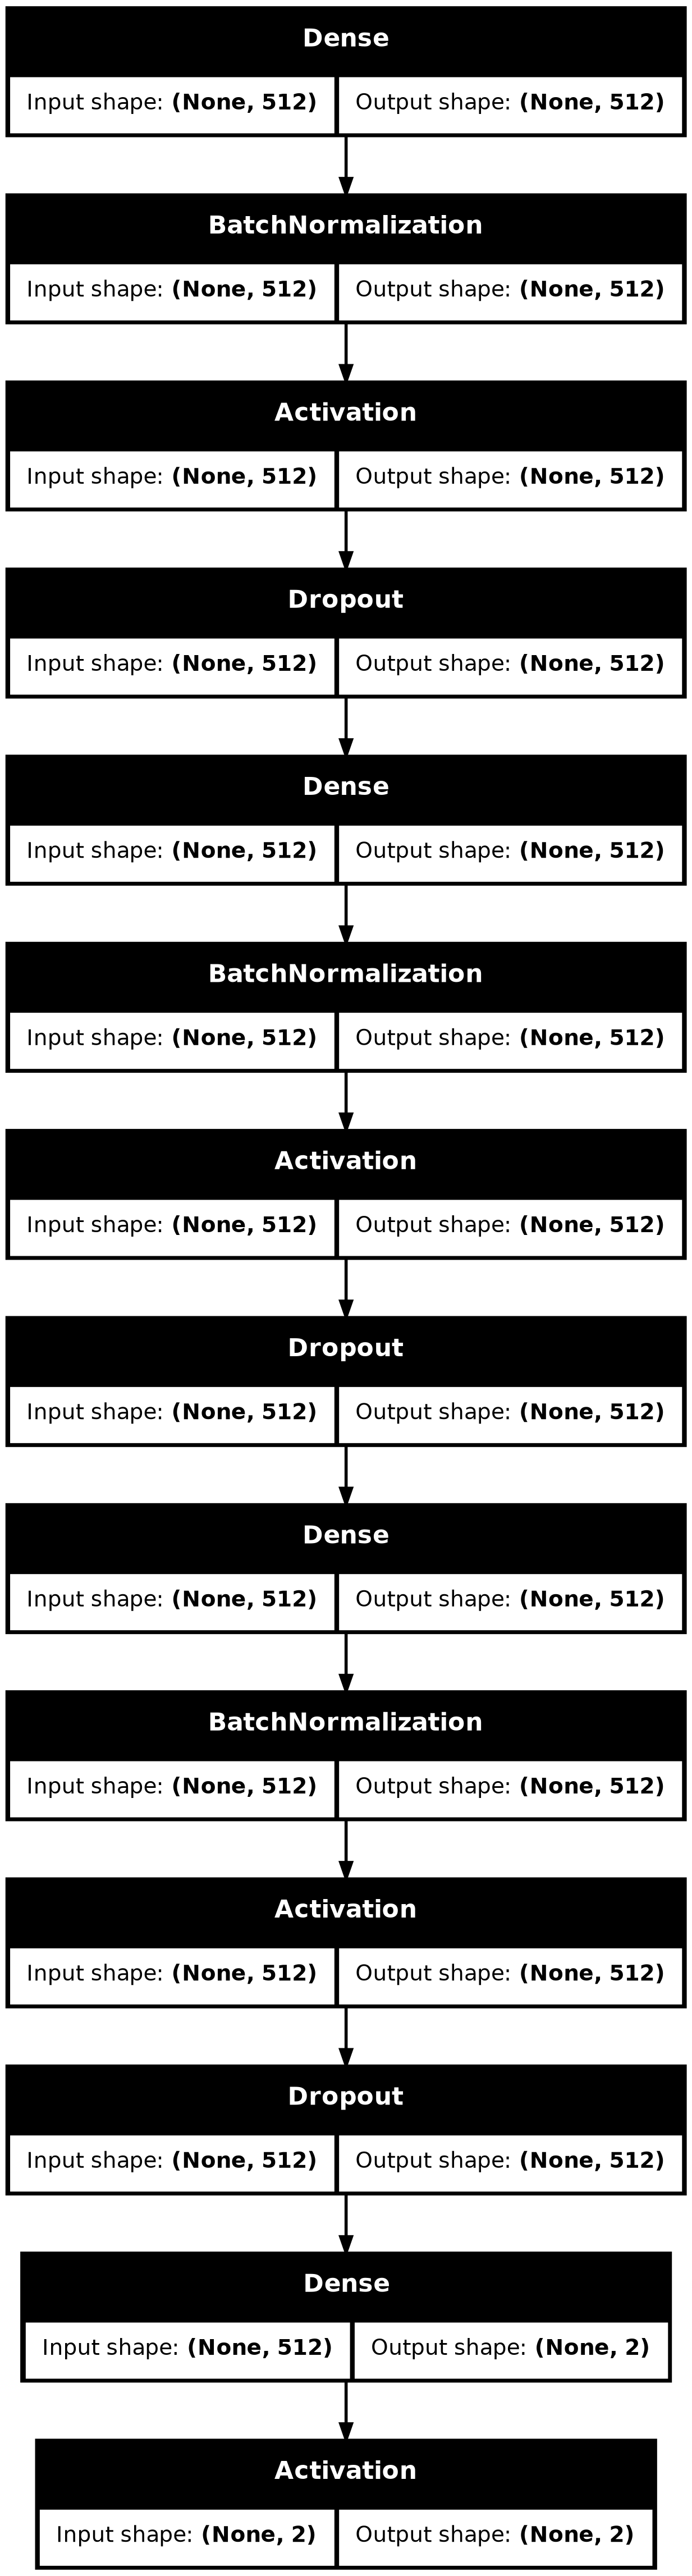

In [21]:
from tensorflow.keras.utils import plot_model

dot_img_file = 'Ch9b - w2v_dnn_model.png'
plot_model(w2v_dnn, to_file=dot_img_file, show_shapes=True)

### Model Training, Prediction and Performance Evaluation

In [41]:
batch_size = 100
w2v_dnn.fit(avg_wv_train_features, y_train, epochs=10, batch_size=batch_size, 
            shuffle=True, validation_split=0.1, verbose=1)
w2v_dnn.save('model_w2v_dnn.keras', zipped=True)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8591 - loss: 0.3397 - val_accuracy: 0.8746 - val_loss: 0.3020
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.8812 - loss: 0.2865 - val_accuracy: 0.8743 - val_loss: 0.3000
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.8838 - loss: 0.2788 - val_accuracy: 0.8783 - val_loss: 0.2941
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.8877 - loss: 0.2711 - val_accuracy: 0.8826 - val_loss: 0.2960
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.8890 - loss: 0.2639 - val_accuracy: 0.8740 - val_loss: 0.3106
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.8914 - loss: 0.2596 - val_accuracy: 0.8780 - val_loss: 0.3022
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.8930 - loss: 0.2551 - val_accuracy: 0.8714 - val_loss: 0.3048
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.8945 - loss: 0.2502 - va

In [42]:
y_pred = np.argmax(w2v_dnn.predict(avg_wv_test_features), axis=-1)
predictions = le.inverse_transform(y_pred) 

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step


In [43]:
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=predictions, 
                                      classes=['positive', 'negative'])  

Model Performance metrics:
------------------------------
Accuracy: 0.8813
Precision: 0.8817
Recall: 0.8813
F1 Score: 0.8813

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.87      0.90      0.88      7510
    negative       0.89      0.87      0.88      7490

    accuracy                           0.88     15000
   macro avg       0.88      0.88      0.88     15000
weighted avg       0.88      0.88      0.88     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6730      780
        negative       1000     6490


In [44]:
glove_dnn = construct_deepnn_architecture(num_input_features=300)

In [26]:
batch_size = 100
glove_dnn.fit(train_glove_features, y_train, epochs=10, batch_size=batch_size, 
              shuffle=True, validation_split=0.1, verbose=1)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8234 - loss: 0.4129 - val_accuracy: 0.8489 - val_loss: 0.3824
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - accuracy: 0.8559 - loss: 0.3322 - val_accuracy: 0.8086 - val_loss: 0.4187
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8663 - loss: 0.3148 - val_accuracy: 0.8403 - val_loss: 0.3586
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.8727 - loss: 0.2997 - val_accuracy: 0.8383 - val_loss: 0.3781
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.8797 - loss: 0.2859 - val_accuracy: 0.8363 - val_loss: 0.3726
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8810 - loss: 0.2740 - val_accuracy: 0.8540 - val_loss: 0.3446
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.8917 - loss: 0.2596 - val_accuracy: 0.8446 - val_loss: 0.3699
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.8976 - loss: 0.2464 - va

In [45]:
glove_dnn.save('model_glove_dnn.keras', zipped=True)

In [50]:
y_pred = np.argmax(glove_dnn.predict(test_glove_features), axis=-1)
predictions = le.inverse_transform(y_pred)

#y_pred = np.where(glove_dnn.predict(test_glove_features, batch_size=100) > 0.5, 1, 0)
#predictions = le.inverse_transform(y_pred.flatten())

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step


In [51]:
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=predictions, 
                                      classes=['positive', 'negative'])  

Model Performance metrics:
------------------------------
Accuracy: 0.4997
Precision: 0.5311
Recall: 0.4997
F1 Score: 0.3359

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.56      0.00      0.01      7510
    negative       0.50      1.00      0.67      7490

    accuracy                           0.50     15000
   macro avg       0.53      0.50      0.34     15000
weighted avg       0.53      0.50      0.34     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive         27     7483
        negative         21     7469
